In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error
from xgboost import XGBClassifier, XGBRegressor

In [92]:
amazon = pd.read_csv('ml_ozon_ounterfeit_test_new_features.csv')

In [4]:

print(amazon.info())

<class 'pandas.DataFrame'>
RangeIndex: 8631 entries, 0 to 8630
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            8631 non-null   int64  
 1   brand_name                    7109 non-null   str    
 2   description                   7463 non-null   str    
 3   name_rus                      8631 non-null   str    
 4   CommercialTypeName4           8631 non-null   str    
 5   rating_1_count                996 non-null    float64
 6   rating_2_count                996 non-null    float64
 7   rating_3_count                996 non-null    float64
 8   rating_4_count                996 non-null    float64
 9   rating_5_count                996 non-null    float64
 10  comments_published_count      996 non-null    float64
 11  photos_published_count        996 non-null    float64
 12  videos_published_count        996 non-null    float64
 13  PriceDiscounte

In [5]:
amazon = amazon.drop('id',axis=1)
amazon = amazon.drop('ItemID',axis=1)
amazon = amazon.drop('SellerID',axis=1)
amazon = amazon.drop('ItemVarietyCount',axis=1)
amazon = amazon.drop('ItemAvailableCount',axis=1)

for i in range(1,6):
    amazon[f'rating_{i}_count'] = amazon[f'rating_{i}_count'].replace(to_replace = np.nan,value = 0.0)
        
amazon['rating_m_count'] =  (amazon['rating_1_count'] * 1 + amazon['rating_2_count'] * 2 + amazon['rating_3_count'] * 3 + amazon['rating_4_count'] * 4 + amazon['rating_5_count'] * 5) /(amazon['rating_1_count'] + amazon['rating_2_count'] + amazon['rating_3_count'] + amazon['rating_4_count'] + amazon['rating_5_count']  + 1)

for i in range(1,6):
    amazon = amazon.drop(f'rating_{i}_count',axis =1)

amazon['comments_published_count'] =amazon['comments_published_count'].replace(to_replace = np.nan,value = 0.0)
amazon['photos_published_count'] =amazon['photos_published_count'].replace(to_replace = np.nan,value = 0.0)
amazon['videos_published_count'] =amazon['videos_published_count'].replace(to_replace = np.nan,value = 0.0)

amazon['published_count'] = amazon['photos_published_count'] + amazon['comments_published_count'] + amazon['videos_published_count']
amazon = amazon.drop('photos_published_count',axis =1)
amazon = amazon.drop('comments_published_count',axis =1)
amazon = amazon.drop('videos_published_count',axis =1)

amazon['total_count_sell'] = amazon['item_count_sales7'] + amazon['item_count_sales30'] + amazon['item_count_sales90']
amazon = amazon.drop('item_count_sales7',axis =1)
amazon = amazon.drop('item_count_sales30',axis =1)
amazon = amazon.drop('item_count_sales90',axis =1)

amazon['total_item_count_fake_return'] = amazon['item_count_fake_returns7'] + amazon['item_count_fake_returns30'] + amazon['item_count_fake_returns90']
amazon = amazon.drop('item_count_fake_returns7',axis =1)
amazon = amazon.drop('item_count_fake_returns30',axis =1)
amazon = amazon.drop('item_count_fake_returns90',axis =1)

amazon['total_item_count_return'] = amazon['item_count_returns7'] + amazon['item_count_returns30'] + amazon['item_count_returns90']
amazon = amazon.drop('item_count_returns7',axis =1)
amazon = amazon.drop('item_count_returns30',axis =1)
amazon = amazon.drop('item_count_returns90',axis =1)

amazon['total_item_count_real_fake_return'] = amazon['total_item_count_return'] / (amazon['total_item_count_fake_return'] + 1)

amazon = amazon.drop('total_item_count_fake_return',axis =1)
amazon = amazon.drop('total_item_count_return',axis =1)

amazon['total_GmvTotal'] = amazon['GmvTotal7'] + amazon['GmvTotal30'] + amazon['GmvTotal90']
amazon = amazon.drop('GmvTotal7',axis =1)
amazon = amazon.drop('GmvTotal30',axis =1)
amazon = amazon.drop('GmvTotal90',axis =1)

amazon['total_ExemplarAC'] = amazon['ExemplarAcceptedCountTotal7'] + amazon['ExemplarAcceptedCountTotal30'] + amazon['ExemplarAcceptedCountTotal90']
amazon = amazon.drop('ExemplarAcceptedCountTotal7',axis =1)
amazon = amazon.drop('ExemplarAcceptedCountTotal30',axis =1)
amazon = amazon.drop('ExemplarAcceptedCountTotal90',axis =1)

amazon['total_orader'] = amazon['OrderAcceptedCountTotal7'] + amazon['OrderAcceptedCountTotal30'] + amazon['OrderAcceptedCountTotal90']
amazon = amazon.drop('OrderAcceptedCountTotal7',axis =1)
amazon = amazon.drop('OrderAcceptedCountTotal30',axis =1)
amazon = amazon.drop('OrderAcceptedCountTotal90',axis =1)

amazon['total_ExemplarRC'] = amazon['ExemplarReturnedCountTotal7'] + amazon['ExemplarReturnedCountTotal30'] + amazon['ExemplarReturnedCountTotal90']
amazon = amazon.drop('ExemplarReturnedCountTotal7',axis =1)
amazon = amazon.drop('ExemplarReturnedCountTotal30',axis =1)
amazon = amazon.drop('ExemplarReturnedCountTotal90',axis =1)

amazon['total_ExemplarRV'] = amazon['ExemplarReturnedValueTotal7'] + amazon['ExemplarReturnedValueTotal30'] + amazon['ExemplarReturnedValueTotal90']
amazon = amazon.drop('ExemplarReturnedValueTotal7',axis =1)
amazon = amazon.drop('ExemplarReturnedValueTotal30',axis =1)
amazon = amazon.drop('ExemplarReturnedValueTotal90',axis =1)

In [67]:
amazon = amazon.drop('id',axis=1)
amazon = amazon.drop('ItemID',axis=1)
amazon = amazon.drop('SellerID',axis=1)
amazon = amazon.drop('ItemVarietyCount',axis=1)
amazon = amazon.drop('ItemAvailableCount',axis=1)

for i in range(1,6):
    amazon[f'rating_{i}_count'] = amazon[f'rating_{i}_count'].replace(to_replace = np.nan,value = 0.0)
        
amazon['rating_m_count'] =  (amazon['rating_1_count'] * 1 + amazon['rating_2_count'] * 2 + amazon['rating_3_count'] * 3 + amazon['rating_4_count'] * 4 + amazon['rating_5_count'] * 5) /(amazon['rating_1_count'] + amazon['rating_2_count'] + amazon['rating_3_count'] + amazon['rating_4_count'] + amazon['rating_5_count']  + 1)

for i in range(1,6):
    amazon = amazon.drop(f'rating_{i}_count',axis =1)

amazon['comments_published_count'] =amazon['comments_published_count'].replace(to_replace = np.nan,value = 0.0)
amazon['photos_published_count'] =amazon['photos_published_count'].replace(to_replace = np.nan,value = 0.0)
amazon['videos_published_count'] =amazon['videos_published_count'].replace(to_replace = np.nan,value = 0.0)

amazon['published_count'] = amazon['photos_published_count'] + amazon['comments_published_count'] + amazon['videos_published_count']
amazon = amazon.drop('photos_published_count',axis =1)
amazon = amazon.drop('comments_published_count',axis =1)
amazon = amazon.drop('videos_published_count',axis =1)

amazon['total_count_sell'] = amazon['item_count_sales90']
amazon = amazon.drop('item_count_sales7',axis =1)
amazon = amazon.drop('item_count_sales30',axis =1)
amazon = amazon.drop('item_count_sales90',axis =1)

amazon['total_item_count_fake_return'] = amazon['item_count_fake_returns90']
amazon = amazon.drop('item_count_fake_returns7',axis =1)
amazon = amazon.drop('item_count_fake_returns30',axis =1)
amazon = amazon.drop('item_count_fake_returns90',axis =1)

amazon['total_item_count_return'] = amazon['item_count_returns90']
amazon = amazon.drop('item_count_returns7',axis =1)
amazon = amazon.drop('item_count_returns30',axis =1)
amazon = amazon.drop('item_count_returns90',axis =1)

amazon['total_item_count_real_fake_return'] = amazon['total_item_count_return'] / (amazon['total_item_count_fake_return'] + 1) / 5

amazon = amazon.drop('total_item_count_fake_return',axis =1)
amazon = amazon.drop('total_item_count_return',axis =1)

amazon['total_GmvTotal'] = amazon['GmvTotal90']
amazon = amazon.drop('GmvTotal7',axis =1)
amazon = amazon.drop('GmvTotal30',axis =1)
amazon = amazon.drop('GmvTotal90',axis =1)

amazon['total_ExemplarAC'] = amazon['ExemplarAcceptedCountTotal90']
amazon = amazon.drop('ExemplarAcceptedCountTotal7',axis =1)
amazon = amazon.drop('ExemplarAcceptedCountTotal30',axis =1)
amazon = amazon.drop('ExemplarAcceptedCountTotal90',axis =1)

amazon['total_orader'] = amazon['OrderAcceptedCountTotal90']
amazon = amazon.drop('OrderAcceptedCountTotal7',axis =1)
amazon = amazon.drop('OrderAcceptedCountTotal30',axis =1)
amazon = amazon.drop('OrderAcceptedCountTotal90',axis =1)

amazon['total_ExemplarRC'] = amazon['ExemplarReturnedCountTotal90']
amazon = amazon.drop('ExemplarReturnedCountTotal7',axis =1)
amazon = amazon.drop('ExemplarReturnedCountTotal30',axis =1)
amazon = amazon.drop('ExemplarReturnedCountTotal90',axis =1)

amazon['total_ExemplarRV'] = amazon['ExemplarReturnedValueTotal90']
amazon = amazon.drop('ExemplarReturnedValueTotal7',axis =1)
amazon = amazon.drop('ExemplarReturnedValueTotal30',axis =1)
amazon = amazon.drop('ExemplarReturnedValueTotal90',axis =1)

amazon = amazon.drop('total_orader',axis=1)
amazon = amazon.drop('total_ExemplarRC',axis=1)
amazon = amazon.drop('brand_name',axis=1)
amazon = amazon.drop('description',axis=1)
amazon = amazon.drop('name_rus',axis=1)
amazon = amazon.drop('CommercialTypeName4',axis=1)

amazon['total_item_count_real_fake_return'] = np.where(amazon['total_item_count_real_fake_return'] > 1, 1, amazon['total_item_count_real_fake_return'])

In [61]:
amazon.columns

Index(['PriceDiscounted', 'item_time_alive', 'seller_time_alive',
       'rating_m_count', 'published_count', 'total_count_sell',
       'total_item_count_real_fake_return', 'total_GmvTotal',
       'total_ExemplarAC', 'total_ExemplarRV'],
      dtype='str')

In [62]:
amazon['total_item_count_fake_return'].unique()

KeyError: 'total_item_count_fake_return'

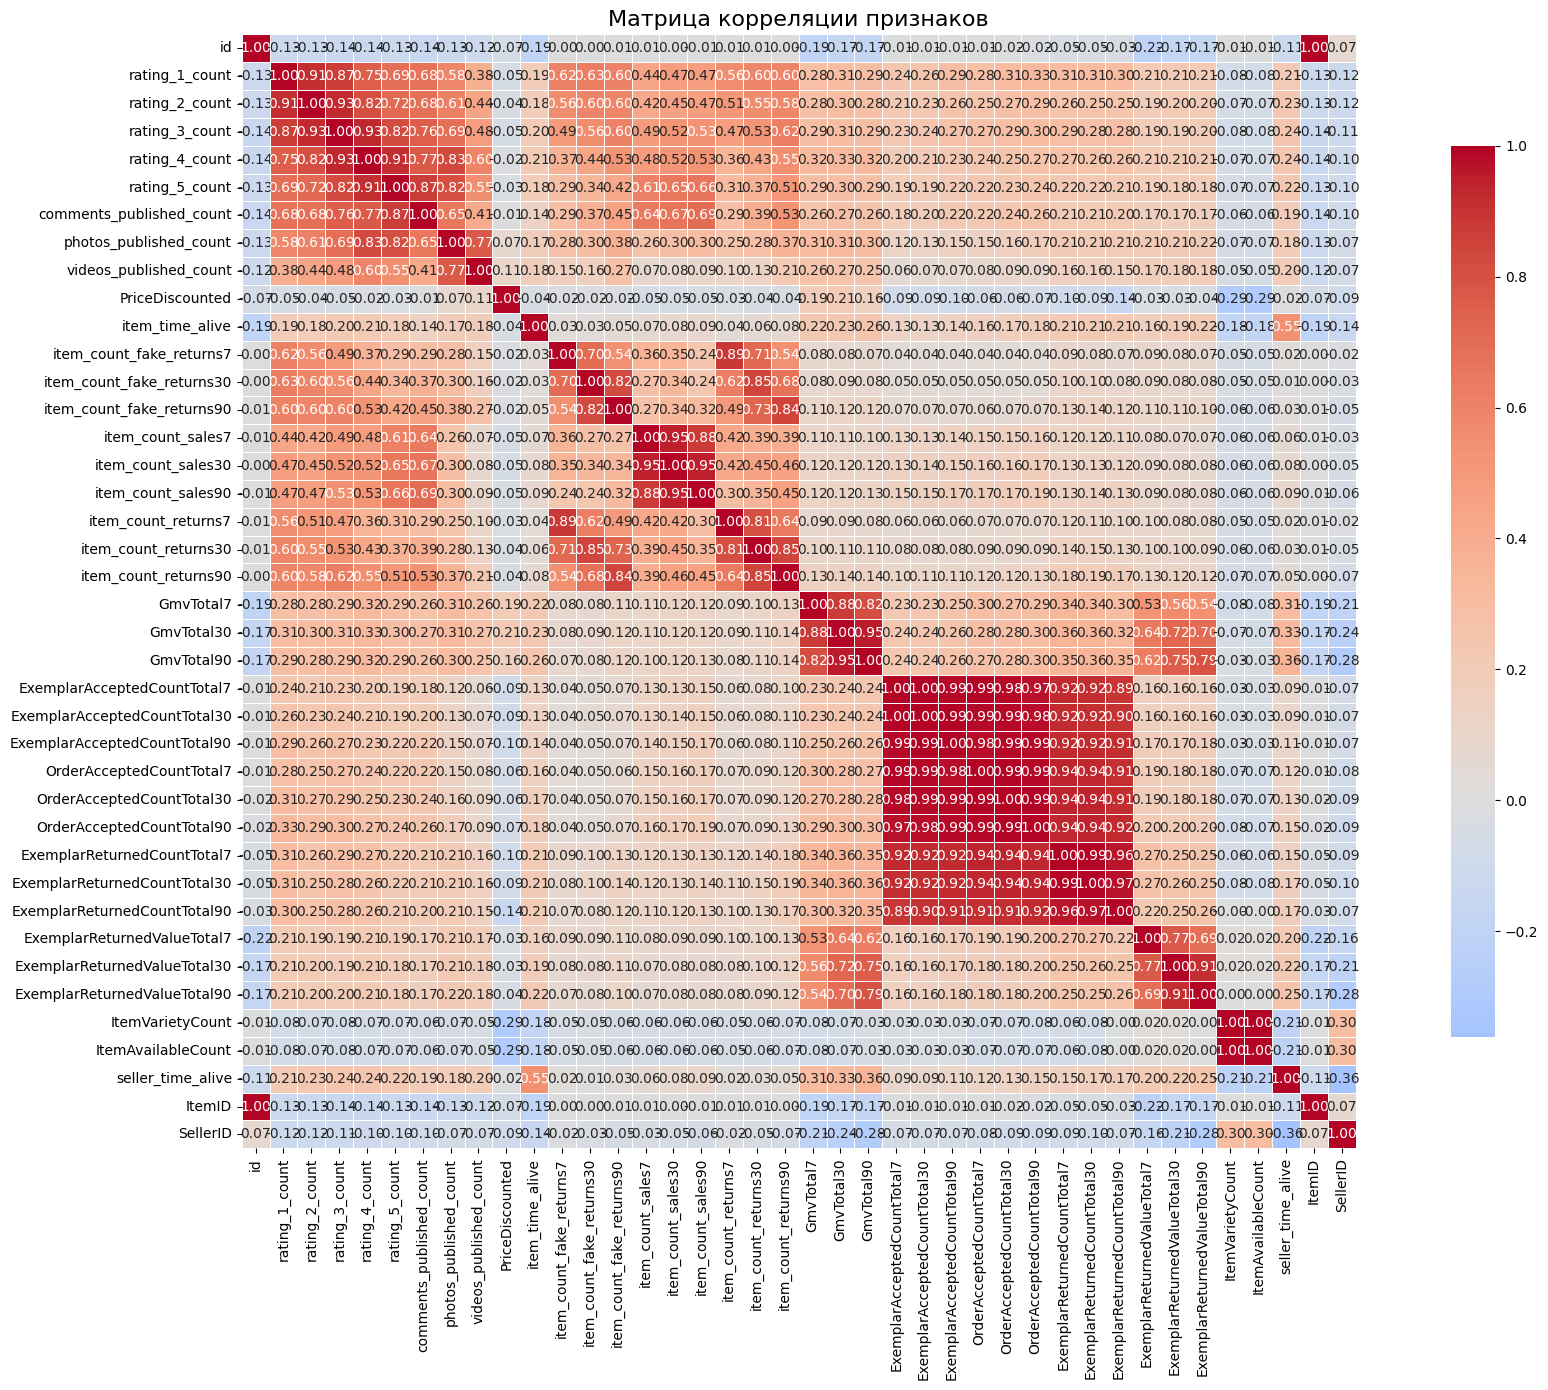

In [95]:
import seaborn as sns


numeric_cols = amazon.select_dtypes(include=[np.number]).columns
amazon_numeric = amazon[numeric_cols]

# 3. Заполняем пропуски (если есть)
# amazon_numeric = amazon_numeric.fillna(0)

# 4. Строим матрицу корреляции
corr_matrix = amazon_numeric.corr()

# 5. Визуализация
plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": 0.8})

plt.title('Матрица корреляции признаков', fontsize=16)
plt.tight_layout()
plt.show()

In [69]:
amazon.describe()

,PriceDiscounted,item_time_alive,seller_time_alive,rating_m_count,published_count,total_count_sell,total_item_count_real_fake_return,total_GmvTotal,total_ExemplarAC,total_ExemplarRV
count,8631.000000,8631.000000,8631.000000,8631.000000,8631.000000,8631.000000,8631.000000,8352.000000,8.352000e+03,8352.000000
mean,821.665377,220.593790,685.514656,0.361338,6.524273,29.457884,0.037568,1486.867216,1.133765e+04,1050.658811
std,213.785430,363.998177,617.615887,1.078619,74.432402,265.890379,0.128711,237.873845,6.255574e+04,425.291276
min,69.629985,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,562.610841,1.000000e+00,0.000000
25%,714.534718,22.000000,161.000000,0.000000,0.000000,0.000000,0.000000,1381.272127,1.730000e+02,1025.325324
50%,828.203078,48.000000,473.000000,0.000000,0.000000,0.000000,0.000000,1511.995307,8.370000e+02,1177.393030
75%,967.708244,254.000000,1109.500000,0.000000,0.000000,1.000000,0.000000,1621.096760,4.379750e+03,1274.820060
max,1449.987598,2313.000000,2443.000000,4.860759,2701.000000,18003.000000,1.000000,2064.980753,1.475890e+06,1724.428434


In [70]:
y = amazon['total_item_count_real_fake_return']
x = amazon.drop('total_item_count_real_fake_return',axis=1)

In [71]:
x_train,x_val,y_train,y_val = train_test_split(x,y,train_size=0.3,random_state=42,shuffle=True)

In [75]:
model = XGBRegressor()

In [76]:
model.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [77]:
amazon['total_item_count_real_fake_return'].unique()

array([0.        , 0.44      , 0.1       , 0.6       , 0.65714286,
       0.13333333, 0.66666667, 0.2       , 0.33333333, 0.46666667,
       1.        , 0.3       , 0.4       , 0.26666667, 0.24444444,
       0.15      , 0.28333333, 0.25      , 0.56      , 0.7       ,
       0.28      , 0.275     , 0.36      , 0.35555556, 0.84      ,
       0.24      , 0.31538462, 0.35      , 0.45      , 0.36666667,
       0.12      , 0.75      , 0.55      , 0.5       , 0.425     ,
       0.16      , 0.38947368, 0.83846154, 0.375     , 0.23333333,
       0.86666667, 0.31      , 0.28571429, 0.30769231, 0.32      ,
       0.05      , 0.84444444, 0.27777778, 0.8       , 0.36363636,
       0.22857143, 0.57142857, 0.14444444, 0.65      , 0.56923077,
       0.48      , 0.52727273, 0.43333333, 0.53333333, 0.25714286,
       0.61666667, 0.54      , 0.31111111, 0.85      , 0.98823529,
       0.33846154, 0.325     , 0.9       , 0.32647059, 0.50769231,
       0.27272727, 0.42222222, 0.24666667, 0.47391304, 0.24035

In [78]:
y_pred = model.predict(x_val)

In [79]:
print(mean_squared_error(y_val,y_pred))

0.008782280672106799


In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(f"MSE: {mean_squared_error(y_val, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_val, y_pred):.4f}")
print(f"R²:  {r2_score(y_val, y_pred):.4f}")

MSE: 0.0088
MAE: 0.0322
R²:  0.4580


In [89]:
n=[y_val,y_pred]
print(y_val[:20])
print(y_pred[:20])

6478    0.000000
2776    0.000000
2648    0.000000
2628    0.000000
1147    0.000000
1421    0.000000
5426    0.000000
1061    0.000000
5990    0.000000
7748    0.000000
2531    0.000000
4228    0.000000
833     0.000000
6620    0.000000
1672    0.000000
3217    0.000000
4189    0.133333
7663    0.000000
5620    0.000000
3625    0.900000
Name: total_item_count_real_fake_return, dtype: float64
[ 1.7181091e-04 -1.5968765e-03  1.8239249e-03 -1.0950930e-03
  1.7896720e-04  8.9814588e-03 -2.8029887e-04  3.1601477e-03
 -3.1058208e-04  1.6335599e-03 -7.1759435e-04  1.8006191e-04
  4.9837399e-04  1.3780609e-02 -1.0586939e-03 -5.1887979e-04
  3.3134320e-01 -2.5397062e-06  2.0352604e-04  3.1979665e-01]


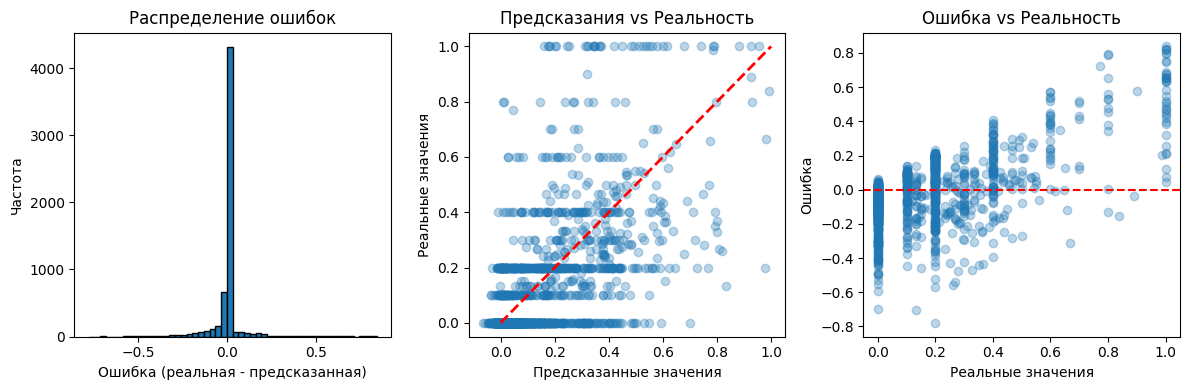

In [83]:
# Посмотрим распределение ошибок
import matplotlib.pyplot as plt
import numpy as np

errors = y_val - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(errors, bins=50, edgecolor='black')
plt.xlabel('Ошибка (реальная - предсказанная)')
plt.ylabel('Частота')
plt.title('Распределение ошибок')

plt.subplot(1, 3, 2)
plt.scatter(y_pred, y_val, alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Предсказания vs Реальность')

plt.subplot(1, 3, 3)
# Ошибка в зависимости от реального значения
plt.scatter(y_val, errors, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Реальные значения')
plt.ylabel('Ошибка')
plt.title('Ошибка vs Реальность')

plt.tight_layout()
plt.show()